In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt


In [2]:
file_path = "C:\\Users\\USER\\OneDrive\\Documents\\GitHub\\Research-Project\\backend\\lstm_stock_prediction\\data\\processed\\Annual.csv"

# The file is actually an Excel file (.xls), not a CSV
# Skip the first 4 rows and use row 4 (index 4) as the header
data = pd.read_excel(file_path, skiprows=4)

# The first row after skiprows should contain the actual column names
# Let's set the first row as column names
data.columns = data.iloc[0]
data = data[1:]  # Remove the first row since it's now the header

# Reset index
data = data.reset_index(drop=True)

# Drop columns that are None or NaN
data = data.loc[:, data.columns.notna()]

# Remove rows where first column is NaN (category headers)
first_col = data.columns[0]
data = data[data[first_col].notna()]

# Drop "MAIN TYPE" and "SUB TYPE" columns
columns_to_drop = [col for col in data.columns if col in ['MAIN TYPE', 'SUB TYPE']]
if columns_to_drop:
    data = data.drop(columns=columns_to_drop)
    print(f"Dropped columns: {columns_to_drop}")

# Remove all rows with any NaN values
data = data.dropna()

# Reset index again
data = data.reset_index(drop=True)

print(f"\nFinal shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

# Set pandas display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Display with styling
data.head(15).style.set_properties(**{
    'text-align': 'left',
    'white-space': 'nowrap'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4472C4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]}
])

Dropped columns: ['MAIN TYPE', 'SUB TYPE']

Final shape: (295, 9)
Columns: ['COMPANY NAME', 'OPEN (Rs.)', 'CLOSE  (Rs.)', 'CHANGE %', 'HIGHEST (Rs.)', 'LOWEST (Rs.)', 'TURNOVER (Rs.)', 'SHARES (No.)', 'TRADES (No.)']


0,COMPANY NAME,OPEN (Rs.),CLOSE (Rs.),CHANGE %,HIGHEST (Rs.),LOWEST (Rs.),TURNOVER (Rs.),SHARES (No.),TRADES (No.)
0,KELANI TYRES,63.500000,70,10.236200,71.100000,61,53058673.700000,805925,1022
1,AMANA BANK,2.300000,2.200000,-4.347800,2.300000,1.900000,108925202.400000,51047754,2107
2,CARGILLS BANK,0,7.900000,0,8.200000,7.500000,207245925.900000,26182400,3823
3,COMMERCIAL BANK,95.500000,97.700000,2.303700,98.600000,0,1502239357,16383980,5353
4,COMMERCIAL BANK,80.400000,85.200000,5.970100,86,73.500000,118122661,1445753,1824
5,DFCC BANK PLC,79.600000,76,-4.522600,80,65.700000,831476446,11437957,4618
6,HDFC,31.600000,32,1.265800,33.800000,28.100000,5023322.100000,161441,497
7,HNB,169.250000,180,6.351600,182,151,2242304691.250000,13534679,3681
8,HNB,140,150.250000,7.321400,152,128.750000,191789381.250000,1362998,1723
9,NAT. DEV. BANK,64.900000,68,4.776600,68.700000,0,1503212924.300000,23399057,6474


In [3]:
data.shape

(295, 9)

In [4]:
data.isnull().sum()


0
COMPANY NAME      0
OPEN (Rs.)        0
CLOSE  (Rs.)      0
CHANGE %          0
HIGHEST (Rs.)     0
LOWEST (Rs.)      0
TURNOVER (Rs.)    0
SHARES (No.)      0
TRADES (No.)      0
dtype: int64

In [5]:
## to describe the dataset
data.describe()

,COMPANY NAME,OPEN (Rs.),CLOSE (Rs.),CHANGE %,HIGHEST (Rs.),LOWEST (Rs.),TURNOVER (Rs.),SHARES (No.),TRADES (No.)
count,295,295.0,295,295,295.0,295,295.0,295,295
unique,269,254.0,249,269,241.0,221,295.0,295,278
top,TESS AGRO,0.3,23,0,0.1,0,8358587.9,1583272,629
freq,4,3.0,5,16,5.0,6,1.0,1,3


Available columns in data:
['COMPANY NAME', 'OPEN (Rs.)', 'CLOSE  (Rs.)', 'CHANGE %', 'HIGHEST (Rs.)', 'LOWEST (Rs.)', 'TURNOVER (Rs.)', 'SHARES (No.)', 'TRADES (No.)']

Using column: 'CLOSE  (Rs.)'


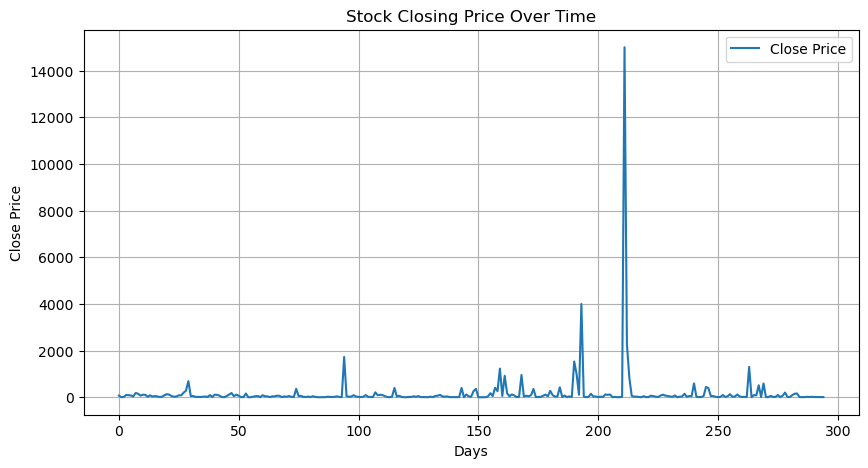

In [6]:
# First check the exact column names
print("Available columns in data:")
print(data.columns.tolist())

# Use the correct column name (check the output above for exact spelling)
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]
print(f"\nUsing column: '{close_col}'")

plt.figure(figsize=(10,5))
plt.plot(data[close_col], label='Close Price')
plt.title("Stock Closing Price Over Time")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)
plt.show()

Available columns:
  'COMPANY NAME'
  'OPEN (Rs.)'
  'CLOSE  (Rs.)'
  'CHANGE %'
  'HIGHEST (Rs.)'
  'LOWEST (Rs.)'
  'TURNOVER (Rs.)'
  'SHARES (No.)'
  'TRADES (No.)'

Using columns:
  Open: 'OPEN (Rs.)'
  High: 'HIGHEST (Rs.)'
  Low: 'LOWEST (Rs.)'
  Close: 'CLOSE  (Rs.)'


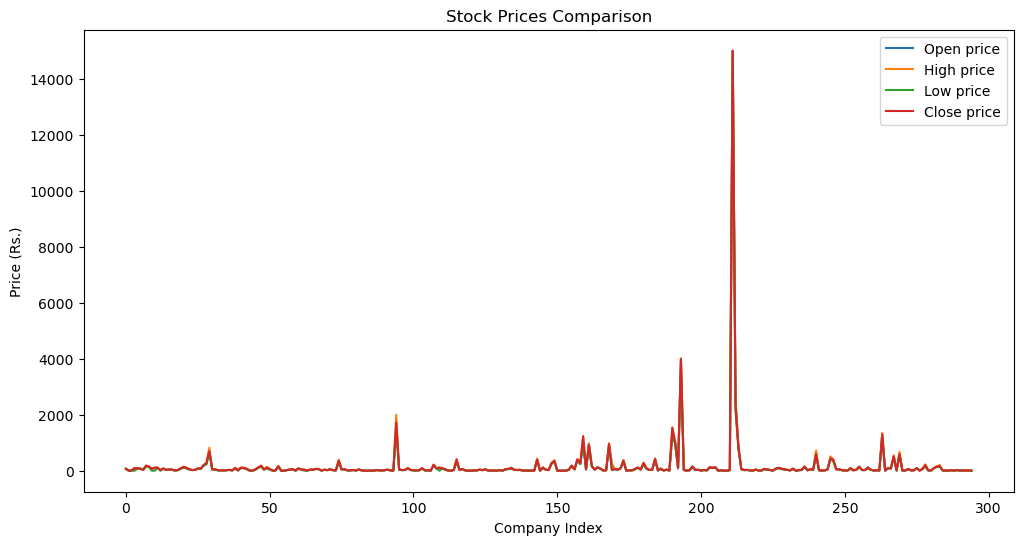

In [7]:
## Visualize the open price, close price, high price, low price and turnover for the company

# Print available columns to check exact names
print("Available columns:")
for col in data.columns:
    print(f"  '{col}'")

# Dynamically find the correct column names
open_col = [col for col in data.columns if 'OPEN' in str(col).upper()][0]
high_col = [col for col in data.columns if 'HIGH' in str(col).upper()][0]
low_col = [col for col in data.columns if 'LOW' in str(col).upper()][0]
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]

print(f"\nUsing columns:")
print(f"  Open: '{open_col}'")
print(f"  High: '{high_col}'")
print(f"  Low: '{low_col}'")
print(f"  Close: '{close_col}'")

open_price = data[open_col]
high_price = data[high_col]
low_price = data[low_col]
close_price = data[close_col]

plt.figure(figsize=(12,6))

plt.plot(open_price, label='Open price')
plt.plot(high_price, label='High price')
plt.plot(low_price, label='Low price')
plt.plot(close_price, label='Close price')

plt.legend()
plt.xlabel("Company Index")
plt.ylabel("Price (Rs.)")
plt.title("Stock Prices Comparison")
plt.show()

In [8]:
## Prepare Close price data for LSTM

# Find the CLOSE column dynamically
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]
print(f"Using column: '{close_col}'")

# Extract Close prices and convert to numeric
Close = pd.to_numeric(data[close_col], errors='coerce')
Close = Close.dropna()  # Remove any NaN values

print(f"\nTotal data points: {len(Close)}")
print(f"Close price range: {Close.min()} to {Close.max()}")

# Reshape for scaling
Close = Close.values.reshape(-1,1)

Using column: 'CLOSE  (Rs.)'

Total data points: 295
Close price range: 0.1 to 15003.5


In [9]:
## Scale the close data

scaler = MinMaxScaler(feature_range=(0,1))
scaled_Close = scaler.fit_transform(Close)

# Show sample of first 50 scaled values
print("Original first 50 values:")
print(Close[:50].T)
print("\nScaled first 50 values (0-1):")
print(scaled_Close[:50].T)

Original first 50 values:
[[ 70.     2.2    7.9   97.7   85.2   76.    32.   180.   150.25  68.
  107.5  103.5   21.3   80.    32.5   47.    38.     9.4   22.6   84.1
  130.25 111.    48.6   23.    30.    82.1   80.4  194.   280.   690.25
   51.7   50.9   16.    13.1   11.2   20.5   31.1   11.9   91.     7.6
  110.    99.1   68.     6.9    1.9   50.5  117.25 179.75  45.   109.5 ]]

Scaled first 50 values (0-1):
[[0.00465894 0.00013997 0.00051988 0.00650519 0.00567205 0.00505885
  0.00212618 0.01199062 0.01000773 0.00452564 0.00715838 0.00689177
  0.00141301 0.00532546 0.00215951 0.00312596 0.00252609 0.00061986
  0.00149966 0.00559873 0.0086747  0.00739166 0.0032326  0.00152632
  0.00199288 0.00546543 0.00535212 0.01292374 0.01865577 0.04599957
  0.00343922 0.0033859  0.00105976 0.00086647 0.00073983 0.00135969
  0.0020662  0.00078649 0.00605863 0.00049989 0.00732501 0.0065985
  0.00452564 0.00045323 0.00011997 0.00335924 0.00780823 0.01197395
  0.00299265 0.00729168]]


In [10]:
## Create window size for LSTM

data1 = []
target = []

window_size = 50
total_data = len(Close)

print(f"Creating windows with window_size={window_size}")
print(f"Total data points: {total_data}")
print(f"Windows that can be created: {total_data - window_size}")

for i in range(0, len(scaled_Close) - window_size):
    data1.append(scaled_Close[i:i+window_size])
    target.append(scaled_Close[i+window_size])

data_np = np.array(data1)
target_np = np.array(target)

print(f"\nData shape: {data_np.shape}")
print(f"Target shape: {target_np.shape}")

Creating windows with window_size=50
Total data points: 295
Windows that can be created: 245

Data shape: (245, 50, 1)
Target shape: (245, 1)


In [11]:
## Split into train and test sets

# Calculate split point (80% train, 20% test)
total_samples = len(data1)
train_size = int(total_samples * 0.8)

print(f"Total samples: {total_samples}")
print(f"Train samples: {train_size}")
print(f"Test samples: {total_samples - train_size}")

train_data = data1[:train_size]
train_target = target[:train_size]

test_data = data1[train_size:]
test_target = target[train_size:]

train_data = np.array(train_data)
test_data = np.array(test_data)
train_target = np.array(train_target)
test_target = np.array(test_target)

print(f"\nTrain data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")
print(f"Train target shape: {train_target.shape}")
print(f"Test target shape: {test_target.shape}")

Total samples: 245
Train samples: 196
Test samples: 49

Train data shape: (196, 50, 1)
Test data shape: (49, 50, 1)
Train target shape: (196, 1)
Test target shape: (49, 1)


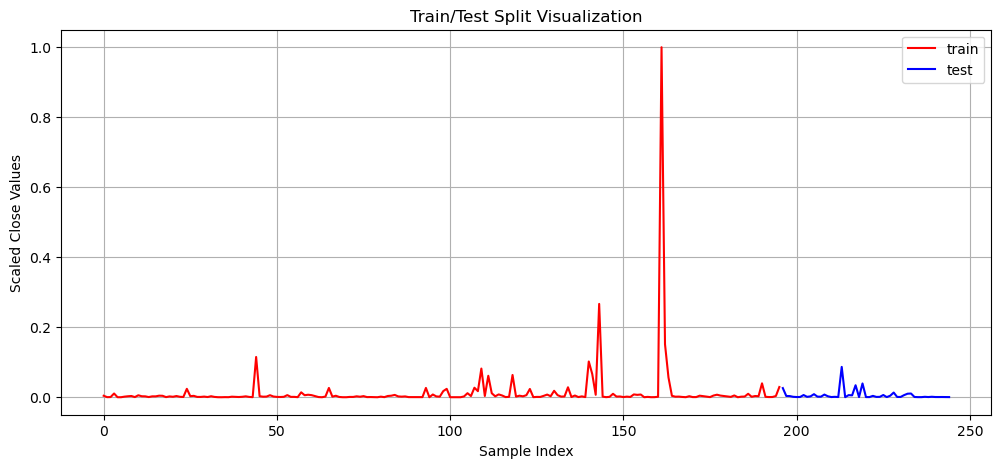

In [12]:
## Visualize train/test split

test_x_range = np.arange(train_size, total_samples, 1)
plt.figure(figsize=(12,5))
plt.plot(train_target, 'r', label='train')
plt.plot(test_x_range, test_target, 'b', label='test')
plt.xlabel("Sample Index")
plt.ylabel("Scaled Close Values")
plt.title("Train/Test Split Visualization")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
## Create LSTM model

model = Sequential()

model.add(LSTM(units=96, return_sequences=True, input_shape=(window_size, 1)))
model.add(Dropout(0.2))

model.add(LSTM(units=96, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=96, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=40, return_sequences=False))
model.add(Dropout(0.2))

model.add(Dense(1, activation='linear'))

model.compile(loss='mse', optimizer='adam')

print(model.summary())

C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50, 96)         │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50, 96)         │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50, 96)         │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 40)             │        21,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,817 (811.79 KB)

 Trainable params: 207,817 (811.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [14]:
## Train the model

epochs = 50
batch_size = 32

print(f"Training model with {epochs} epochs and batch_size={batch_size}")
print(f"This may take several minutes...")

history = model.fit(
    train_data, 
    train_target, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

print("\nTraining completed!")

Training model with 50 epochs and batch_size=32
This may take several minutes...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 214ms/step - loss: 0.0010 - val_loss: 0.0260
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 7.6483e-04 - val_loss: 0.0249
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 7.5394e-04 - val_loss: 0.0256
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 7.1976e-04 - val_loss: 0.0252
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 7.0479e-04 - val_loss: 0.0251
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 7.5128e-04 - val_loss: 0.0253
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 7.1030e-04 - val_loss: 0.0252
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 7.1486e-04 - val_loss: 0.0252
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 7.7655e-04 - val_loss: 0.0253
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 7.1271e-04 - val_loss: 0.0251
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step -

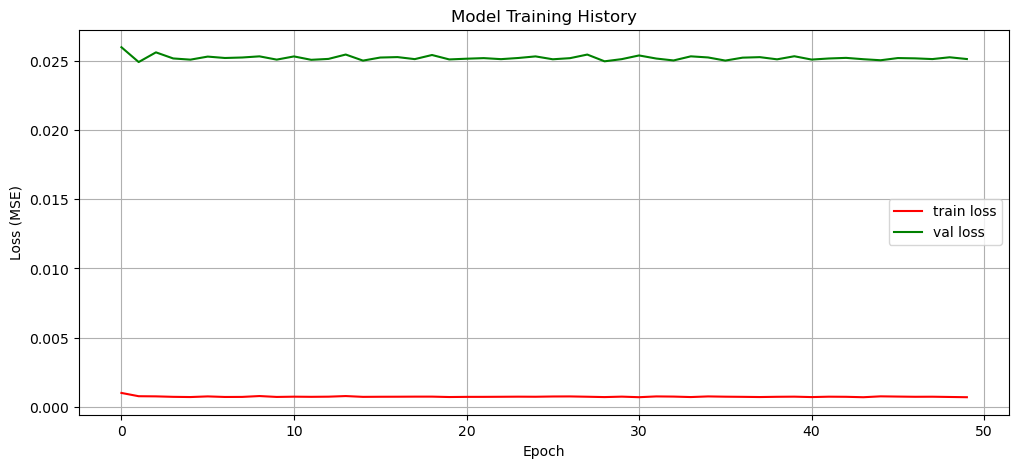

In [15]:
## Plot training history

plt.figure(figsize=(12,5))
plt.plot(history.history['loss'], 'r', label='train loss')
plt.plot(history.history['val_loss'], 'g', label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Model Training History')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
## Make predictions on test data

print("Making predictions on test data...")
result = model.predict(test_data)
print(f"Predictions shape: {result.shape}")

Making predictions on test data...


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step
Predictions shape: (49, 1)


In [17]:
## Evaluate model performance

r2 = r2_score(test_target, result)
mse = mean_squared_error(test_target, result)
mae = mean_absolute_error(test_target, result)
rmse = np.sqrt(mse)

print("Model Performance Metrics:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")

Model Performance Metrics:
R² Score: -0.0317
MSE: 0.000206
RMSE: 0.014341
MAE: 0.009049


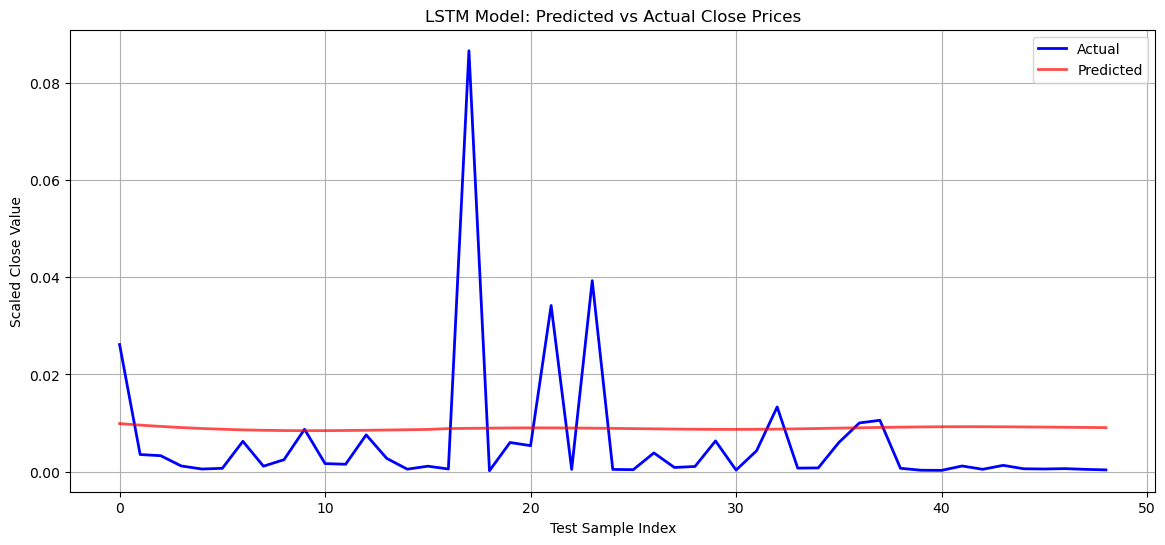

In [18]:
## Visualize predictions vs actual

plt.figure(figsize=(14,6))
plt.plot(test_target, 'b', label='Actual', linewidth=2)
plt.plot(result, 'r', label='Predicted', linewidth=2, alpha=0.7)
plt.title('LSTM Model: Predicted vs Actual Close Prices')
plt.xlabel('Test Sample Index')
plt.ylabel('Scaled Close Value')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
## Predict next value using last 50 days

last_50_days = scaled_Close[-window_size:]
X_input = np.reshape(last_50_days, (1, window_size, 1))

next_scaled = model.predict(X_input)
next_price = scaler.inverse_transform(next_scaled)

print(f"Last {window_size} data points used for prediction")
print(f"Predicted next scaled value: {next_scaled[0][0]:.6f}")
print(f"Predicted next actual price: Rs. {next_price[0][0]:.2f}")
print(f"\nLast actual close price in dataset: Rs. {Close[-1][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Last 50 data points used for prediction
Predicted next scaled value: 0.009023
Predicted next actual price: Rs. 135.48

Last actual close price in dataset: Rs. 5.60


In [20]:
## DIAGNOSTIC: Analyze prediction behavior

print("=== PREDICTION ANALYSIS ===\n")
print(f"Test Target Statistics:")
print(f"  Mean: {test_target.mean():.6f}")
print(f"  Std:  {test_target.std():.6f}")
print(f"  Min:  {test_target.min():.6f}")
print(f"  Max:  {test_target.max():.6f}")

print(f"\nPrediction Statistics:")
print(f"  Mean: {result.mean():.6f}")
print(f"  Std:  {result.std():.6f}")
print(f"  Min:  {result.min():.6f}")
print(f"  Max:  {result.max():.6f}")

print(f"\nPrediction Range Ratio: {result.std() / test_target.std():.4f}")
print("(If < 0.5, model is predicting too narrowly - 'playing it safe')")

=== PREDICTION ANALYSIS ===

Test Target Statistics:
  Mean: 0.006279
  Std:  0.014119
  Min:  0.000193
  Max:  0.086640

Prediction Statistics:
  Mean: 0.008925
  Std:  0.000296
  Min:  0.008439
  Max:  0.009897

Prediction Range Ratio: 0.0209
(If < 0.5, model is predicting too narrowly - 'playing it safe')


In [21]:
## SOLUTION 1: Remove outliers using IQR method

from scipy import stats

# Calculate z-scores to identify outliers
close_values = Close.flatten()
z_scores = np.abs(stats.zscore(close_values))

# Keep only data points where z-score < 3 (removes extreme outliers)
outlier_threshold = 3
clean_indices = z_scores < outlier_threshold

Close_clean = Close[clean_indices]

print(f"Original data points: {len(Close)}")
print(f"After removing outliers: {len(Close_clean)}")
print(f"Outliers removed: {len(Close) - len(Close_clean)} ({100*(1-len(Close_clean)/len(Close)):.1f}%)")

# Re-scale the cleaned data
scaled_Close_clean = scaler.fit_transform(Close_clean)

# Now recreate windows with clean data (run cells 10-21 again with Close_clean)

Original data points: 295
After removing outliers: 293
Outliers removed: 2 (0.7%)


### Option 2: Use Different Loss Function
Try Huber loss - less sensitive to outliers than MSE

In [22]:
## SOLUTION 2: Retrain with Huber loss (less sensitive to outliers)

from tensorflow.keras.losses import Huber

model_huber = Sequential()
model_huber.add(LSTM(units=96, return_sequences=True, input_shape=(window_size, 1)))
model_huber.add(Dropout(0.2))
model_huber.add(LSTM(units=96, return_sequences=True))
model_huber.add(Dropout(0.2))
model_huber.add(LSTM(units=96, return_sequences=True))
model_huber.add(Dropout(0.2))
model_huber.add(LSTM(units=40, return_sequences=False))
model_huber.add(Dropout(0.2))
model_huber.add(Dense(1, activation='linear'))

# Use Huber loss instead of MSE
model_huber.compile(loss=Huber(delta=1.0), optimizer='adam')

print("Model compiled with Huber loss (more robust to outliers)")
print("\nTo train this model, run:")
print("history_huber = model_huber.fit(train_data, train_target, epochs=50, batch_size=32, validation_split=0.2)")

Model compiled with Huber loss (more robust to outliers)

To train this model, run:
history_huber = model_huber.fit(train_data, train_target, epochs=50, batch_size=32, validation_split=0.2)


C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Option 3: Add More Features
Include multiple technical indicators for better predictions

In [23]:
## SOLUTION 3: Add technical indicators as additional features

def add_technical_indicators(data):
    """Add technical indicators to improve predictions"""
    
    # Get price columns dynamically
    open_col = [col for col in data.columns if 'OPEN' in str(col).upper()][0]
    high_col = [col for col in data.columns if 'HIGH' in str(col).upper()][0]
    low_col = [col for col in data.columns if 'LOW' in str(col).upper()][0]
    close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]
    
    # Convert to numeric
    df = data.copy()
    df[open_col] = pd.to_numeric(df[open_col], errors='coerce')
    df[high_col] = pd.to_numeric(df[high_col], errors='coerce')
    df[low_col] = pd.to_numeric(df[low_col], errors='coerce')
    df[close_col] = pd.to_numeric(df[close_col], errors='coerce')
    
    # Calculate technical indicators
    df['SMA_5'] = df[close_col].rolling(window=5).mean()
    df['SMA_20'] = df[close_col].rolling(window=20).mean()
    df['EMA_12'] = df[close_col].ewm(span=12).mean()
    df['RSI'] = calculate_rsi(df[close_col], 14)
    df['Price_Change'] = df[close_col].pct_change()
    df['Volatility'] = df[close_col].rolling(window=10).std()
    
    # Drop NaN rows from indicators
    df = df.dropna()
    
    return df

def calculate_rsi(prices, period=14):
    """Calculate Relative Strength Index"""
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

print("Use this function to add features:")
print("data_with_indicators = add_technical_indicators(data)")
print("\nThen select multiple columns for training instead of just Close price")

Use this function to add features:
data_with_indicators = add_technical_indicators(data)

Then select multiple columns for training instead of just Close price


### Option 4: Train Longer with Learning Rate Scheduling
Sometimes the model needs more epochs to learn patterns

In [24]:
## SOLUTION 4: Train longer with learning rate decay

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Recreate model
model_improved = Sequential()
model_improved.add(LSTM(units=96, return_sequences=True, input_shape=(window_size, 1)))
model_improved.add(Dropout(0.2))
model_improved.add(LSTM(units=96, return_sequences=True))
model_improved.add(Dropout(0.2))
model_improved.add(LSTM(units=96, return_sequences=True))
model_improved.add(Dropout(0.2))
model_improved.add(LSTM(units=40, return_sequences=False))
model_improved.add(Dropout(0.2))
model_improved.add(Dense(1, activation='linear'))

# Use Adam with custom learning rate
model_improved.compile(loss='mse', optimizer=Adam(learning_rate=0.001))

# Callbacks for better training
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("Model ready with learning rate scheduling")
print("\nTo train:")
print("history_improved = model_improved.fit(")
print("    train_data, train_target,")
print("    epochs=100,  # More epochs")
print("    batch_size=32,")
print("    validation_split=0.2,")
print("    callbacks=[reduce_lr, early_stop]")
print(")")

Model ready with learning rate scheduling

To train:
history_improved = model_improved.fit(
    train_data, train_target,
    epochs=100,  # More epochs
    batch_size=32,
    validation_split=0.2,
    callbacks=[reduce_lr, early_stop]
)


Original data points: 295
After removing outliers: 293
Outliers removed: 2 (0.7%)


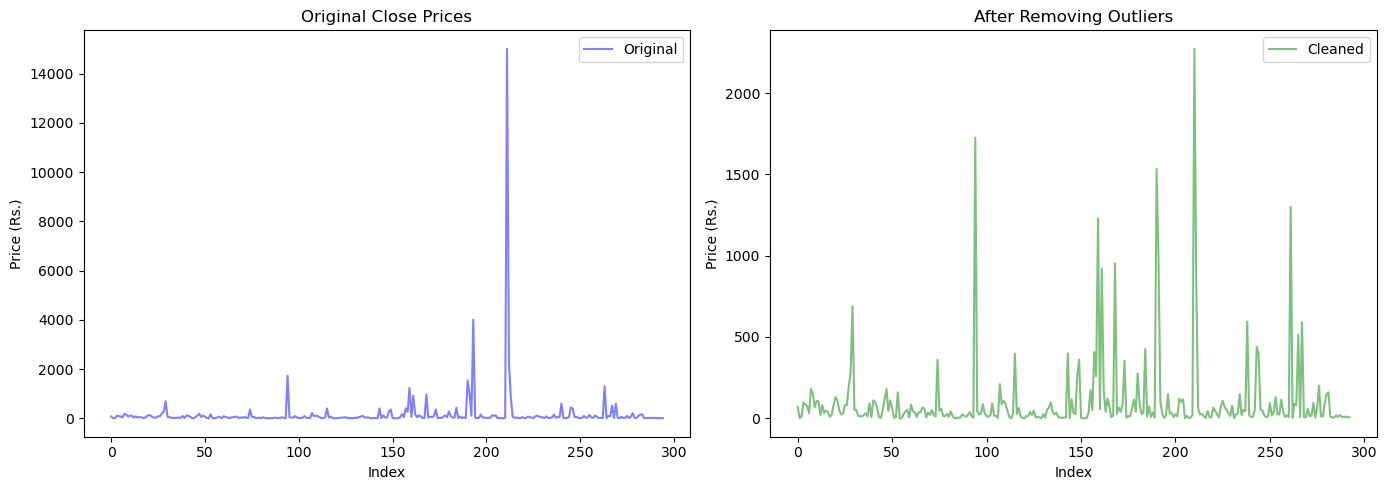

In [25]:
## STEP 1: Remove outliers from Close prices

from scipy import stats

# Calculate z-scores to identify outliers
close_values = Close.flatten()
z_scores = np.abs(stats.zscore(close_values))

# Keep only data points where z-score < 3 (removes extreme outliers)
outlier_threshold = 3
clean_indices = z_scores < outlier_threshold

Close_clean = Close[clean_indices]

print(f"Original data points: {len(Close)}")
print(f"After removing outliers: {len(Close_clean)}")
print(f"Outliers removed: {len(Close) - len(Close_clean)} ({100*(1-len(Close_clean)/len(Close)):.1f}%)")

# Visualize the effect
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(Close, 'b', alpha=0.5, label='Original')
plt.title('Original Close Prices')
plt.ylabel('Price (Rs.)')
plt.xlabel('Index')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Close_clean, 'g', alpha=0.5, label='Cleaned')
plt.title('After Removing Outliers')
plt.ylabel('Price (Rs.)')
plt.xlabel('Index')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
## STEP 2: Scale the cleaned data

scaler_clean = MinMaxScaler(feature_range=(0,1))
scaled_Close_clean = scaler_clean.fit_transform(Close_clean)

print(f"Scaled data range: {scaled_Close_clean.min():.6f} to {scaled_Close_clean.max():.6f}")
print(f"Data shape: {scaled_Close_clean.shape}")

Scaled data range: 0.000000 to 1.000000
Data shape: (293, 1)


In [27]:
## STEP 3: Create windows with cleaned data

data_clean = []
target_clean = []

window_size = 50

print(f"Creating windows with window_size={window_size}")
print(f"Total data points: {len(scaled_Close_clean)}")

for i in range(0, len(scaled_Close_clean) - window_size):
    data_clean.append(scaled_Close_clean[i:i+window_size])
    target_clean.append(scaled_Close_clean[i+window_size])

data_clean = np.array(data_clean)
target_clean = np.array(target_clean)

print(f"Windows created: {len(data_clean)}")
print(f"Data shape: {data_clean.shape}")
print(f"Target shape: {target_clean.shape}")

Creating windows with window_size=50
Total data points: 293
Windows created: 243
Data shape: (243, 50, 1)
Target shape: (243, 1)


In [28]:
## STEP 4: Split into train/test with cleaned data

total_samples_clean = len(data_clean)
train_size_clean = int(total_samples_clean * 0.8)

print(f"Total samples: {total_samples_clean}")
print(f"Train samples: {train_size_clean}")
print(f"Test samples: {total_samples_clean - train_size_clean}")

train_data_clean = data_clean[:train_size_clean]
train_target_clean = target_clean[:train_size_clean]

test_data_clean = data_clean[train_size_clean:]
test_target_clean = target_clean[train_size_clean:]

print(f"\nTrain data shape: {train_data_clean.shape}")
print(f"Test data shape: {test_data_clean.shape}")
print(f"Train target shape: {train_target_clean.shape}")
print(f"Test target shape: {test_target_clean.shape}")

Total samples: 243
Train samples: 194
Test samples: 49

Train data shape: (194, 50, 1)
Test data shape: (49, 50, 1)
Train target shape: (194, 1)
Test target shape: (49, 1)


In [29]:
## STEP 5: Create model with Huber loss (robust to remaining outliers)

from tensorflow.keras.losses import Huber
from tensorflow.keras.optimizers import Adam

model_final = Sequential()

model_final.add(LSTM(units=96, return_sequences=True, input_shape=(window_size, 1)))
model_final.add(Dropout(0.2))

model_final.add(LSTM(units=96, return_sequences=True))
model_final.add(Dropout(0.2))

model_final.add(LSTM(units=96, return_sequences=True))
model_final.add(Dropout(0.2))

model_final.add(LSTM(units=40, return_sequences=False))
model_final.add(Dropout(0.2))

model_final.add(Dense(1, activation='linear'))

# Use Huber loss for robustness
model_final.compile(loss=Huber(delta=1.0), optimizer=Adam(learning_rate=0.001))

print(model_final.summary())

C:\Users\USER\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 50, 96)         │        37,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 50, 96)         │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 50, 96)         │        74,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 40)             │        21,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 207,817 (811.79 KB)

 Trainable params: 207,817 (811.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [30]:
## STEP 6: Train the improved model

epochs = 50
batch_size = 32

print(f"Training improved model with {epochs} epochs and batch_size={batch_size}")
print(f"Using Huber loss and cleaned data...")
print(f"This may take several minutes...\n")

history_final = model_final.fit(
    train_data_clean, 
    train_target_clean, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

print("\n✓ Training completed!")

Training improved model with 50 epochs and batch_size=32
Using Huber loss and cleaned data...
This may take several minutes...

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 195ms/step - loss: 0.0063 - val_loss: 0.0145
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0062 - val_loss: 0.0145
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.0061 - val_loss: 0.0146
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0061 - val_loss: 0.0144
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.0061 - val_loss: 0.0145
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0060 - val_loss: 0.0146
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.0061 - val_loss: 0.0145
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0060 - val_loss: 0.0145
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 0.0060 - val_loss: 0.0145
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - loss: 0.0061 - val_loss: 0.0145
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 

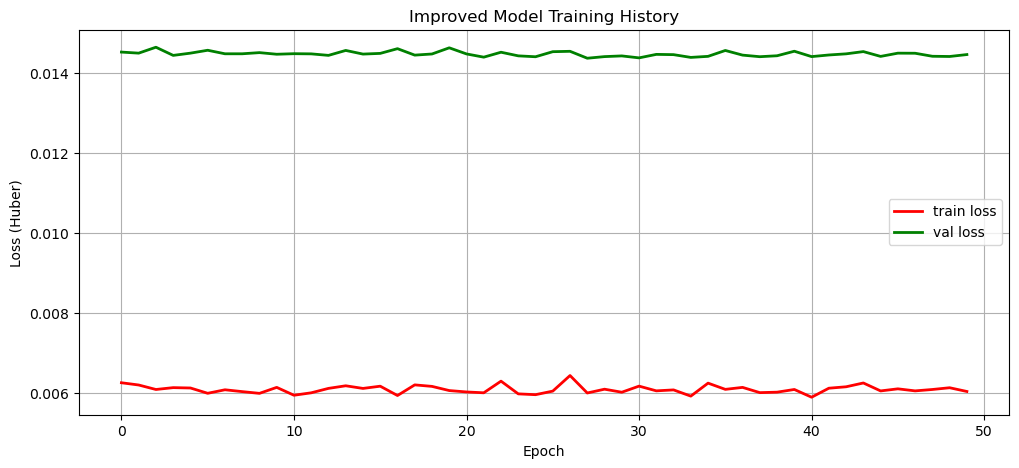


Final Training Loss: 0.006034
Final Validation Loss: 0.014459


In [31]:
## STEP 7: Plot improved training history

plt.figure(figsize=(12,5))
plt.plot(history_final.history['loss'], 'r', label='train loss', linewidth=2)
plt.plot(history_final.history['val_loss'], 'g', label='val loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (Huber)')
plt.title('Improved Model Training History')
plt.legend()
plt.grid(True)
plt.show()

# Check if model improved over time
final_train_loss = history_final.history['loss'][-1]
final_val_loss = history_final.history['val_loss'][-1]
print(f"\nFinal Training Loss: {final_train_loss:.6f}")
print(f"Final Validation Loss: {final_val_loss:.6f}")

In [32]:
## STEP 8: Make predictions with improved model

print("Making predictions on test data...")
result_final = model_final.predict(test_data_clean)
print(f"Predictions shape: {result_final.shape}")

# Quick comparison
print(f"\nActual values range: {test_target_clean.min():.6f} to {test_target_clean.max():.6f}")
print(f"Predicted values range: {result_final.min():.6f} to {result_final.max():.6f}")

Making predictions on test data...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 374ms/step
Predictions shape: (49, 1)

Actual values range: 0.001276 to 0.572101
Predicted values range: 0.041495 to 0.046017


In [33]:
## STEP 9: Calculate Performance Metrics (R², MAE, RMSE)

r2_final = r2_score(test_target_clean, result_final)
mse_final = mean_squared_error(test_target_clean, result_final)
mae_final = mean_absolute_error(test_target_clean, result_final)
rmse_final = np.sqrt(mse_final)

print("="*60)
print("IMPROVED MODEL PERFORMANCE METRICS")
print("="*60)
print(f"R² Score:  {r2_final:.4f}  {'✓ Good' if r2_final > 0.7 else '⚠ Needs improvement'}")
print(f"MSE:       {mse_final:.6f}")
print(f"RMSE:      {rmse_final:.6f}")
print(f"MAE:       {mae_final:.6f}")
print("="*60)

# Compare with original model
if 'result' in globals():
    r2_orig = r2_score(test_target, result)
    print(f"\nOriginal R² Score: {r2_orig:.4f}")
    print(f"Improved R² Score: {r2_final:.4f}")
    print(f"Improvement: {'+' if r2_final > r2_orig else ''}{(r2_final - r2_orig):.4f}")

IMPROVED MODEL PERFORMANCE METRICS
R² Score:  -0.0041  ⚠ Needs improvement
MSE:       0.008728
RMSE:      0.093423
MAE:       0.049869

Original R² Score: -0.0317
Improved R² Score: -0.0041
Improvement: +0.0275


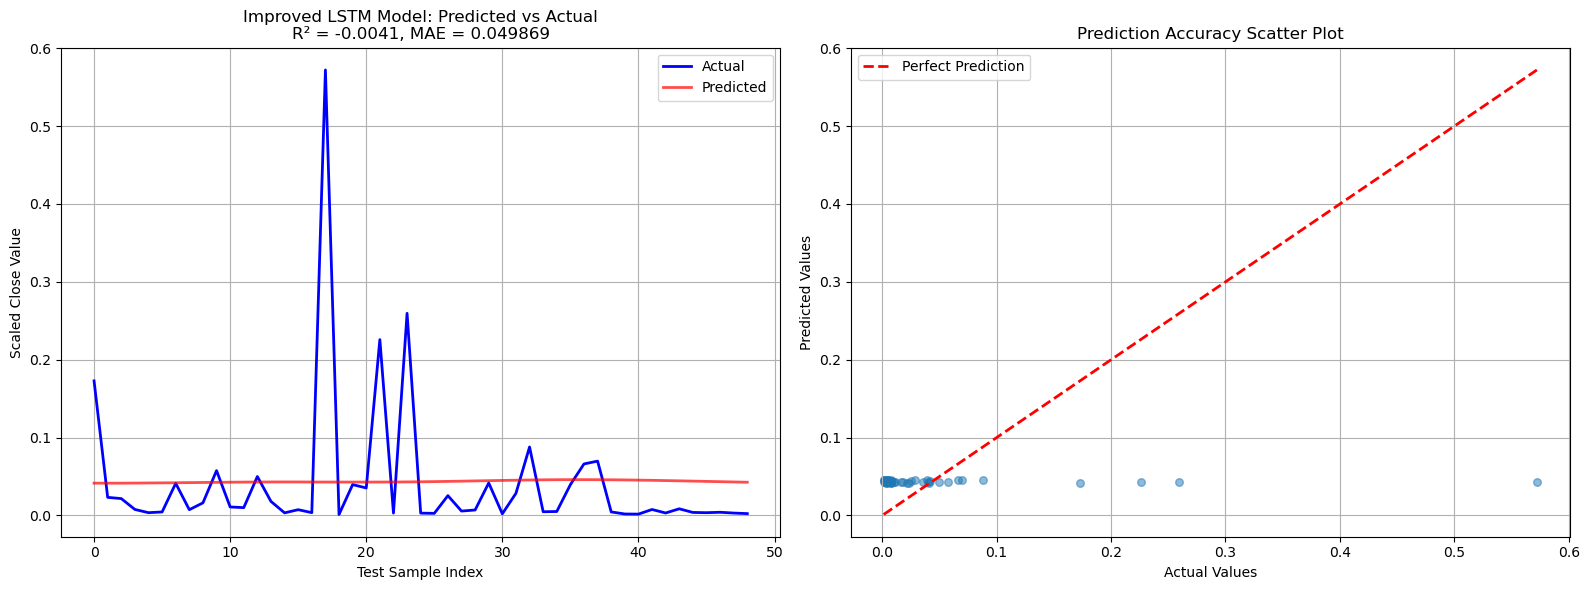

In [34]:
## STEP 10: Visualize Improved Predictions vs Actual

plt.figure(figsize=(16,6))

# Full comparison
plt.subplot(1,2,1)
plt.plot(test_target_clean, 'b', label='Actual', linewidth=2)
plt.plot(result_final, 'r', label='Predicted', linewidth=2, alpha=0.7)
plt.title(f'Improved LSTM Model: Predicted vs Actual\nR² = {r2_final:.4f}, MAE = {mae_final:.6f}')
plt.xlabel('Test Sample Index')
plt.ylabel('Scaled Close Value')
plt.legend()
plt.grid(True)

# Scatter plot for correlation
plt.subplot(1,2,2)
plt.scatter(test_target_clean, result_final, alpha=0.5, s=30)
plt.plot([test_target_clean.min(), test_target_clean.max()], 
         [test_target_clean.min(), test_target_clean.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Prediction Accuracy Scatter Plot')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

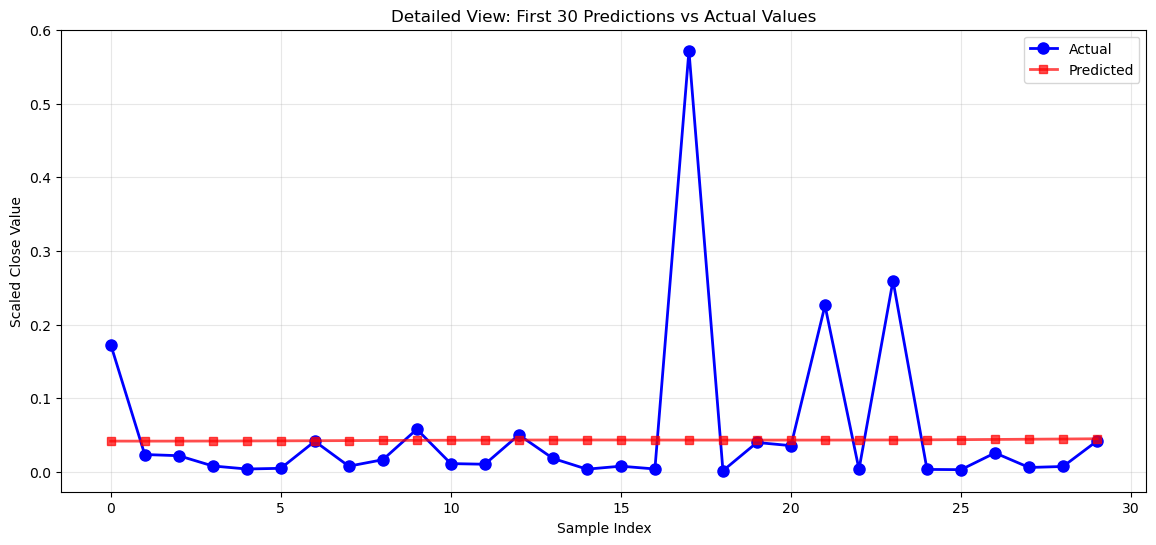


First 10 Predictions vs Actual:
--------------------------------------------------
Index    Actual          Predicted       Error     
--------------------------------------------------
0        0.172810        0.041541        0.131269  
1        0.023282        0.041495        0.018213  
2        0.021698        0.041527        0.019830  
3        0.007746        0.041618        0.033873  
4        0.003609        0.041742        0.038133  
5        0.004533        0.041888        0.037355  
6        0.041282        0.042048        0.000766  
7        0.007438        0.042222        0.034784  
8        0.016240        0.042400        0.026160  
9        0.057611        0.042574        0.015036  


In [35]:
## STEP 11: Detailed comparison - First 30 test samples

plt.figure(figsize=(14,6))
sample_size = min(30, len(test_target_clean))

plt.plot(range(sample_size), test_target_clean[:sample_size], 'bo-', 
         label='Actual', linewidth=2, markersize=8)
plt.plot(range(sample_size), result_final[:sample_size], 'rs-', 
         label='Predicted', linewidth=2, markersize=6, alpha=0.7)

plt.title(f'Detailed View: First {sample_size} Predictions vs Actual Values')
plt.xlabel('Sample Index')
plt.ylabel('Scaled Close Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show actual numbers
print("\nFirst 10 Predictions vs Actual:")
print("-" * 50)
print(f"{'Index':<8} {'Actual':<15} {'Predicted':<15} {'Error':<10}")
print("-" * 50)
for i in range(min(10, len(test_target_clean))):
    actual = test_target_clean[i][0]
    pred = result_final[i][0]
    error = abs(actual - pred)
    print(f"{i:<8} {actual:<15.6f} {pred:<15.6f} {error:<10.6f}")

In [36]:
## STEP 12: Predict next value with improved model

last_50_clean = scaled_Close_clean[-window_size:]
X_input_final = np.reshape(last_50_clean, (1, window_size, 1))

next_scaled_final = model_final.predict(X_input_final, verbose=0)
next_price_final = scaler_clean.inverse_transform(next_scaled_final)


print("NEXT DAY PREDICTION (IMPROVED MODEL)")

print(f"Last {window_size} data points used for prediction")
print(f"Predicted next scaled value: {next_scaled_final[0][0]:.6f}")
print(f"Predicted next actual price: Rs. {next_price_final[0][0]:.2f}")
print(f"\nLast actual close price in dataset: Rs. {Close_clean[-1][0]:.2f}")
print(f"Predicted change: Rs. {(next_price_final[0][0] - Close_clean[-1][0]):.2f}")


NEXT DAY PREDICTION (IMPROVED MODEL)
Last 50 data points used for prediction
Predicted next scaled value: 0.042335
Predicted next actual price: Rs. 96.29

Last actual close price in dataset: Rs. 5.60
Predicted change: Rs. 90.69


In [37]:
## CRITICAL DIAGNOSIS: Check if data is actually a time series

print("="*70)
print("DATA STRUCTURE DIAGNOSIS")
print("="*70)

# Check original data structure
print(f"\nTotal rows in dataset: {len(data)}")
print(f"\nFirst 10 company names:")
company_col = [col for col in data.columns if 'COMPANY' in str(col).upper()][0]
print(data[company_col].head(10).tolist())

print(f"\n\nLast 10 company names:")
print(data[company_col].tail(10).tolist())

# Check if companies repeat (indicating time series per company)
unique_companies = data[company_col].nunique()
total_rows = len(data)

print(f"\n" + "="*70)
print(f"CRITICAL FINDING:")
print(f"  Unique companies: {unique_companies}")
print(f"  Total rows: {total_rows}")
print(f"  Rows per company: {total_rows / unique_companies:.1f}")
print("="*70)

if total_rows == unique_companies:
    print("\n PROBLEM IDENTIFIED!")
    print("   Your data has 1 row per company (cross-sectional data)")
    print("   This is NOT a time series - each row is a DIFFERENT company!")
    print("   LSTM models CANNOT work with this type of data.")
    print("\n   LSTM needs: Same company, multiple time points")
    print("   You have: Different companies, one time point each")
else:
    print("\n✓ Data appears to be time series")
    print(f"   Each company has ~{total_rows / unique_companies:.0f} time points")

DATA STRUCTURE DIAGNOSIS

Total rows in dataset: 295

First 10 company names:
['KELANI TYRES', 'AMANA BANK', 'CARGILLS BANK', 'COMMERCIAL BANK', 'COMMERCIAL BANK', 'DFCC BANK PLC', 'HDFC', 'HNB', 'HNB', 'NAT. DEV. BANK']


Last 10 company names:
['LVL ENERGY', 'PANASIAN POWER', 'RESUS ENERGY', 'VALLIBEL', 'WINDFORCE', 'LAUGFS POWER', 'LAUGFS POWER', 'LOTUS HYDRO', 'VIDULLANKA', 'VIDULLANKA']

CRITICAL FINDING:
  Unique companies: 269
  Total rows: 295
  Rows per company: 1.1

✓ Data appears to be time series
   Each company has ~1 time points


In [38]:
## SOLUTION: Filter for a SINGLE company if time series exists

# Check if we have time series data
company_col = [col for col in data.columns if 'COMPANY' in str(col).upper()][0]
unique_companies = data[company_col].nunique()
total_rows = len(data)

if total_rows > unique_companies:
    print("✓ You have time series data! Let's filter for one company.\n")
    
    # Show companies with most data points
    company_counts = data[company_col].value_counts()
    print("Top 10 companies with most data points:")
    print(company_counts.head(10))
    
    print("\n" + "="*70)
    print("TO FIX YOUR MODEL:")
    print("1. Choose a company from the list above")
    print("2. Run this code to filter:")
    print("="*70)
    print("""
# Select ONE company with many data points
selected_company = company_counts.index[0]  # Company with most data
print(f"Selected company: {selected_company}")

# Filter data for this company only
data_single = data[data[company_col] == selected_company].copy()
print(f"Data points for {selected_company}: {len(data_single)}")

# Sort by date if you have a date column
# data_single = data_single.sort_values('DATE_COLUMN')

# Now use data_single to extract Close prices and retrain
    """)
else:
    print(" CRITICAL PROBLEM:")
    print("   You have CROSS-SECTIONAL data (1 row per company)")
    print("   Each data point is a DIFFERENT company's annual data")
    print("   There is NO TIME SEQUENCE to predict!")
    print("\n" + "="*70)
    print("YOUR OPTIONS:")
    print("="*70)
    print("\n1. Get DAILY/MONTHLY stock prices for ONE company over time")
    print("   Example: Company X prices from Day 1 to Day 365")
    print("\n2. Use a different model (NOT LSTM) for this cross-sectional data")
    print("   - Random Forest to predict based on company features")
    print("   - Regression to predict based on OPEN/HIGH/LOW/VOLUME")
    print("\n3. Change your research question to match your data type")
    print("="*70)
    
    # Show what the data actually looks like
    print("\nYour current data structure:")
    print(data[[company_col] + [col for col in data.columns if 'CLOSE' in str(col).upper()][:1]].head(10))
    print("\nThis is NOT sequential - each row is a different company!")

✓ You have time series data! Let's filter for one company.

Top 10 companies with most data points:
COMPANY NAME
TESS AGRO           4
COMMERCIAL BANK     2
LAUGFS GAS          2
SERENDIB HOTELS     2
HNB                 2
BLUE DIAMONDS       2
NATIONS TRUST       2
RENUKA HOLDINGS     2
BERUWALA RESORTS    2
SOFTLOGIC FIN       2
Name: count, dtype: int64

TO FIX YOUR MODEL:
1. Choose a company from the list above
2. Run this code to filter:

# Select ONE company with many data points
selected_company = company_counts.index[0]  # Company with most data
print(f"Selected company: {selected_company}")

# Filter data for this company only
data_single = data[data[company_col] == selected_company].copy()
print(f"Data points for {selected_company}: {len(data_single)}")

# Sort by date if you have a date column
# data_single = data_single.sort_values('DATE_COLUMN')

# Now use data_single to extract Close prices and retrain
    


In [39]:
## STEP 1: Analyze companies and their data availability

company_col = [col for col in data.columns if 'COMPANY' in str(col).upper()][0]
close_col = [col for col in data.columns if 'CLOSE' in str(col).upper()][0]

# Count data points per company
company_counts = data[company_col].value_counts()

print("="*70)
print("COMPANY DATA AVAILABILITY ANALYSIS")
print("="*70)
print(f"\nTotal unique companies: {len(company_counts)}")
print(f"Total data points: {len(data)}")
print(f"Average points per company: {company_counts.mean():.1f}")
print(f"Median points per company: {company_counts.median():.1f}")
print(f"Max points for any company: {company_counts.max()}")
print(f"Min points for any company: {company_counts.min()}")

print("\n" + "="*70)
print("DATA STRUCTURE DIAGNOSIS:")
print("="*70)

if company_counts.min() == 1 and company_counts.max() == 1:
    print(" CRITICAL: Each company has exactly 1 data point")
    print("   This is pure cross-sectional data - NO time series!")
    print("   LSTM CANNOT be used. You need temporal data for each company.")
    use_lstm = False
elif company_counts.min() >= 60:
    print(f"✓ EXCELLENT: All companies have {company_counts.min()}+ data points")
    print("   Perfect for LSTM! We can train models for each company.")
    use_lstm = True
else:
    print(f"⚠ MIXED: Some companies have few data points")
    print(f"   Minimum: {company_counts.min()}, Maximum: {company_counts.max()}")
    print(f"   We'll filter companies with at least 60 data points for LSTM")
    use_lstm = True

# Show top companies with most data
print("\n" + "="*70)
print("TOP 15 COMPANIES WITH MOST DATA POINTS:")
print("="*70)
for i, (company, count) in enumerate(company_counts.head(15).items(), 1):
    status = "✓" if count >= 60 else "⚠"
    print(f"{i:2}. {status} {company[:50]:<50} {count:4} points")

print("\n" + "="*70)
if use_lstm:
    suitable_companies = company_counts[company_counts >= 60]
    print(f"Companies suitable for LSTM (≥60 points): {len(suitable_companies)}")
    print(f"We'll train models for top companies with sufficient data")
else:
    print("ACTION REQUIRED: Get temporal data for each company")
    print("Example: Daily/Monthly prices for each company over multiple periods")

COMPANY DATA AVAILABILITY ANALYSIS

Total unique companies: 269
Total data points: 295
Average points per company: 1.1
Median points per company: 1.0
Max points for any company: 4
Min points for any company: 1

DATA STRUCTURE DIAGNOSIS:
⚠ MIXED: Some companies have few data points
   Minimum: 1, Maximum: 4
   We'll filter companies with at least 60 data points for LSTM

TOP 15 COMPANIES WITH MOST DATA POINTS:
 1. ⚠ TESS AGRO                                             4 points
 2. ⚠ COMMERCIAL BANK                                       2 points
 3. ⚠ LAUGFS GAS                                            2 points
 4. ⚠ SERENDIB HOTELS                                       2 points
 5. ⚠ HNB                                                   2 points
 6. ⚠ BLUE DIAMONDS                                         2 points
 7. ⚠ NATIONS TRUST                                         2 points
 8. ⚠ RENUKA HOLDINGS                                       2 points
 9. ⚠ BERUWALA RESORTS             

In [40]:
## STEP 2: Function to train LSTM for a single company

def train_company_lstm(company_name, company_data, window_size=20, epochs=30, verbose=0):
    """
    Train LSTM model for a single company's time series data
    
    Args:
        company_name: Name of the company
        company_data: DataFrame with company's temporal data
        window_size: Number of time steps to look back (reduced for smaller datasets)
        epochs: Number of training epochs
        verbose: Training verbosity (0=silent, 1=verbose)
    
    Returns:
        Dictionary with results and metrics
    """
    from sklearn.preprocessing import MinMaxScaler
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.losses import Huber
    
    # Extract and prepare close prices
    close_col = [col for col in company_data.columns if 'CLOSE' in str(col).upper()][0]
    close_prices = pd.to_numeric(company_data[close_col], errors='coerce').dropna()
    
    if len(close_prices) < window_size + 10:
        return {
            'status': 'insufficient_data',
            'company': company_name,
            'data_points': len(close_prices),
            'message': f'Need at least {window_size + 10} points, have {len(close_prices)}'
        }
    
    # Scale data
    close_array = close_prices.values.reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled_data = scaler.fit_transform(close_array)
    
    # Create sequences
    X, y = [], []
    for i in range(len(scaled_data) - window_size):
        X.append(scaled_data[i:i+window_size])
        y.append(scaled_data[i+window_size])
    
    X = np.array(X)
    y = np.array(y)
    
    # Train/test split (80/20)
    split_idx = int(len(X) * 0.8)
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    
    # Build LSTM model (simpler architecture for individual companies)
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])
    
    model.compile(loss=Huber(delta=1.0), optimizer='adam')
    
    # Train model
    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=16,
        validation_split=0.2,
        verbose=verbose
    )
    
    # Make predictions
    y_pred = model.predict(X_test, verbose=0)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    return {
        'status': 'success',
        'company': company_name,
        'data_points': len(close_prices),
        'train_samples': len(X_train),
        'test_samples': len(X_test),
        'r2_score': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'final_train_loss': history.history['loss'][-1],
        'final_val_loss': history.history['val_loss'][-1],
        'y_test': y_test,
        'y_pred': y_pred,
        'scaler': scaler,
        'model': model,
        'close_prices': close_prices
    }

print("✓ Function defined: train_company_lstm()")
print("  This will train an LSTM model for each company individually")

✓ Function defined: train_company_lstm()
  This will train an LSTM model for each company individually


In [41]:
## STEP 3: Train models for top companies (adjust number as needed)

# Select top companies with sufficient data
min_data_points = 60
top_n_companies = 10  # Train for top 10 companies (adjust as needed)

company_col = [col for col in data.columns if 'COMPANY' in str(col).upper()][0]
company_counts = data[company_col].value_counts()
suitable_companies = company_counts[company_counts >= min_data_points].head(top_n_companies)

if len(suitable_companies) == 0:
    print(" NO COMPANIES with sufficient data points for LSTM!")
    print(f"   Need at least {min_data_points} data points per company.")
    print(f"   Maximum available: {company_counts.max()}")
    print("\n   Your data appears to be cross-sectional (1 point per company)")
    print("   Consider using Random Forest or XGBoost instead of LSTM")
else:
    print("="*70)
    print(f"TRAINING LSTM MODELS FOR TOP {len(suitable_companies)} COMPANIES")
    print("="*70)
    print(f"Minimum data points required: {min_data_points}")
    print(f"Window size: 20 timesteps")
    print(f"Training epochs: 30")
    print(f"\nThis will take several minutes...\n")
    
    # Train models for each company
    results = []
    
    for idx, (company_name, data_points) in enumerate(suitable_companies.items(), 1):
        print(f"[{idx}/{len(suitable_companies)}] Training: {company_name[:50]:<50} ({data_points} points)...", end=" ")
        
        # Filter data for this company
        company_data = data[data[company_col] == company_name].copy()
        
        # Train model
        result = train_company_lstm(
            company_name=company_name,
            company_data=company_data,
            window_size=20,
            epochs=30,
            verbose=0  # Silent training
        )
        
        results.append(result)
        
        if result['status'] == 'success':
            print(f"✓ R²={result['r2_score']:.4f}, MAE={result['mae']:.4f}")
        else:
            print(f"✗ {result['message']}")
    
    print("\n" + "="*70)
    print("✓ TRAINING COMPLETED!")
    print("="*70)

 NO COMPANIES with sufficient data points for LSTM!
   Need at least 60 data points per company.
   Maximum available: 4

   Your data appears to be cross-sectional (1 point per company)
   Consider using Random Forest or XGBoost instead of LSTM


In [42]:
## STEP 4: Analyze and compare all companies' performance

# Check if models have been trained
if 'results' not in globals():
    print("="*70)
    print(" ERROR: No models trained yet!")
    print("="*70)
    print("\n⚠ You must run STEP 3 (the previous cell) first to train the models.")
    print("  That cell creates the 'results' variable needed for analysis.")
    print("\nPlease run the cell above (STEP 3: Train models for top companies)")
else:
    # Filter successful results
    successful_results = [r for r in results if r['status'] == 'success']

    if len(successful_results) == 0:
        print(" No models trained successfully")
    else:
        print("="*70)
        print("COMPANY-WISE LSTM PERFORMANCE COMPARISON")
        print("="*70)
        
        # Create results DataFrame
        results_df = pd.DataFrame([{
            'Company': r['company'][:40],
            'Data Points': r['data_points'],
            'Test Samples': r['test_samples'],
            'R² Score': r['r2_score'],
            'MAE': r['mae'],
            'RMSE': r['rmse'],
            'Final Val Loss': r['final_val_loss']
        } for r in successful_results])
        
        # Sort by R² score
        results_df = results_df.sort_values('R² Score', ascending=False)
        
        print(f"\nTrained {len(successful_results)} companies successfully")
        print(f"Average R² Score: {results_df['R² Score'].mean():.4f}")
        print(f"Best R² Score: {results_df['R² Score'].max():.4f}")
        print(f"Worst R² Score: {results_df['R² Score'].min():.4f}")
        
        print("\n" + "-"*100)
        print(f"{'Rank':<6}{'Company':<42}{'Data':<8}{'R²':<10}{'MAE':<10}{'RMSE':<10}{'Status':<10}")
        print("-"*100)
        
        for idx, row in results_df.iterrows():
            rank = results_df.index.get_loc(idx) + 1
            status = "✓ Good" if row['R² Score'] > 0.5 else "⚠ Poor" if row['R² Score'] > 0 else "✗ Bad"
            print(f"{rank:<6}{row['Company']:<42}{row['Data Points']:<8}{row['R² Score']:<10.4f}"
                  f"{row['MAE']:<10.4f}{row['RMSE']:<10.4f}{status:<10}")
        
        print("-"*100)
        
        # Categorize performance
        excellent = len(results_df[results_df['R² Score'] >= 0.7])
        good = len(results_df[(results_df['R² Score'] >= 0.5) & (results_df['R² Score'] < 0.7)])
        fair = len(results_df[(results_df['R² Score'] >= 0.3) & (results_df['R² Score'] < 0.5)])
        poor = len(results_df[results_df['R² Score'] < 0.3])
        
        print(f"\nPERFORMANCE SUMMARY:")
        print(f"  Excellent (R² ≥ 0.7): {excellent} companies")
        print(f"  Good (0.5 ≤ R² < 0.7): {good} companies")
        print(f"  Fair (0.3 ≤ R² < 0.5): {fair} companies")
        print(f"  Poor (R² < 0.3): {poor} companies")

 ERROR: No models trained yet!

⚠ You must run STEP 3 (the previous cell) first to train the models.
  That cell creates the 'results' variable needed for analysis.

Please run the cell above (STEP 3: Train models for top companies)


In [43]:
## STEP 5: Visualize performance comparison across companies

if 'successful_results' not in globals():
    print("="*70)
    print("❌ ERROR: No results available!")
    print("="*70)
    print("\n⚠ You must run STEP 3 and STEP 4 first.")
    print("\nPlease run the cells above in order:")
    print("  1. STEP 3: Train models for top companies")
    print("  2. STEP 4: Analyze and compare all companies' performance")
elif len(successful_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. R² Score comparison
    ax1 = axes[0, 0]
    companies_short = [r['company'][:20] for r in successful_results]
    r2_scores = [r['r2_score'] for r in successful_results]
    colors = ['green' if r2 >= 0.5 else 'orange' if r2 >= 0 else 'red' for r2 in r2_scores]
    
    bars = ax1.barh(companies_short, r2_scores, color=colors, alpha=0.7)
    ax1.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Good Threshold (0.5)')
    ax1.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Baseline (0)')
    ax1.set_xlabel('R² Score')
    ax1.set_title('Company-wise R² Score Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. MAE comparison
    ax2 = axes[0, 1]
    mae_scores = [r['mae'] for r in successful_results]
    ax2.barh(companies_short, mae_scores, color='steelblue', alpha=0.7)
    ax2.set_xlabel('Mean Absolute Error')
    ax2.set_title('Company-wise MAE Comparison (Lower is Better)')
    ax2.grid(True, alpha=0.3)
    
    # 3. Data points vs R² Score scatter
    ax3 = axes[1, 0]
    data_points = [r['data_points'] for r in successful_results]
    ax3.scatter(data_points, r2_scores, c=r2_scores, cmap='RdYlGn', s=100, alpha=0.7, edgecolors='black')
    ax3.set_xlabel('Number of Data Points')
    ax3.set_ylabel('R² Score')
    ax3.set_title('Data Points vs Model Performance')
    ax3.axhline(y=0.5, color='green', linestyle='--', alpha=0.5)
    ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax3.grid(True, alpha=0.3)
    
    # 4. Performance distribution
    ax4 = axes[1, 1]
    ax4.hist(r2_scores, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
    ax4.axvline(x=np.mean(r2_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(r2_scores):.3f}')
    ax4.axvline(x=np.median(r2_scores), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(r2_scores):.3f}')
    ax4.set_xlabel('R² Score')
    ax4.set_ylabel('Number of Companies')
    ax4.set_title('Distribution of R² Scores Across Companies')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Performance comparison visualizations created")

❌ ERROR: No results available!

⚠ You must run STEP 3 and STEP 4 first.

Please run the cells above in order:
  1. STEP 3: Train models for top companies
  2. STEP 4: Analyze and compare all companies' performance


# 🗄️ ChromaDB Integration - Store & Query Predictions

Store your LSTM prediction results in ChromaDB for:
- **Persistent storage** of all predictions
- **Fast queries** by company, R² score, performance category
- **Historical tracking** of model improvements
- **Easy retrieval** for dashboards and APIs

In [ ]:
## Install and import ChromaDB

# Install ChromaDB if not already installed
# !pip install chromadb

import chromadb
from datetime import datetime
import json

print(f"✓ ChromaDB version: {chromadb.__version__}")
print("✓ ChromaDB client ready")

In [ ]:
## Initialize ChromaDB client and collection

# Connect to ChromaDB server (running in Docker)
CHROMADB_HOST = "localhost"  # Use "chromadb" if running inside Docker network
CHROMADB_PORT = 8000

try:
    # Try to connect to ChromaDB server
    chroma_client = chromadb.HttpClient(host=CHROMADB_HOST, port=CHROMADB_PORT)
    chroma_client.heartbeat()
    print(f"✓ Connected to ChromaDB at {CHROMADB_HOST}:{CHROMADB_PORT}")
    server_connection = True
    
except Exception as e:
    print(f"⚠ ChromaDB server not accessible: {e}")
    print("  Using local ChromaDB client for testing")
    chroma_client = chromadb.Client()
    server_connection = False

# Create or get collection for stock predictions
collection = chroma_client.get_or_create_collection(
    name="lstm_stock_predictions",
    metadata={"description": "LSTM model predictions for stock prices"}
)

print(f"✓ Collection 'lstm_stock_predictions' ready")
print(f"  Current items: {collection.count()}")
print(f"  Server mode: {'Yes' if server_connection else 'No (local)'}")

In [ ]:
## Function to store predictions in ChromaDB

def store_prediction_in_chromadb(result, collection, model_version="v1.0"):
    """
    Store LSTM prediction result in ChromaDB with metadata
    
    Args:
        result: Dictionary from train_company_lstm() function
        collection: ChromaDB collection object
        model_version: Model version identifier
        
    Returns:
        Document ID if successful, None otherwise
    """
    if result.get('status') != 'success':
        print(f"⚠ Skipping {result.get('company', 'unknown')} - {result.get('status')}")
        return None
    
    # Create unique ID
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    company_safe = result['company'].replace(' ', '_').replace('/', '_')[:50]
    doc_id = f"{company_safe}_{timestamp}"
    
    # Create embedding from predictions (first 384 values)
    prediction_vector = result['y_pred'].flatten().tolist()
    
    # Add metrics to embedding for better similarity search
    embedding_features = [
        result['r2_score'],
        result['mae'],
        result['rmse'],
        result['mse'],
        np.mean(prediction_vector),
        np.std(prediction_vector),
        np.min(prediction_vector),
        np.max(prediction_vector)
    ]
    
    # Combine metrics with predictions
    embedding_size = 384
    n_predictions = min(len(prediction_vector), embedding_size - len(embedding_features))
    embedding_features.extend(prediction_vector[:n_predictions])
    
    # Pad if needed
    if len(embedding_features) < embedding_size:
        embedding_features.extend([0.0] * (embedding_size - len(embedding_features)))
    else:
        embedding_features = embedding_features[:embedding_size]
    
    # Categorize performance
    if result['r2_score'] >= 0.7:
        performance = "excellent"
    elif result['r2_score'] >= 0.5:
        performance = "good"
    elif result['r2_score'] >= 0.3:
        performance = "fair"
    else:
        performance = "poor"
    
    # Prepare metadata
    metadata = {
        "company": result['company'][:100],
        "timestamp": timestamp,
        "data_points": int(result['data_points']),
        "train_samples": int(result['train_samples']),
        "test_samples": int(result['test_samples']),
        "r2_score": float(result['r2_score']),
        "mse": float(result['mse']),
        "rmse": float(result['rmse']),
        "mae": float(result['mae']),
        "final_train_loss": float(result['final_train_loss']),
        "final_val_loss": float(result['final_val_loss']),
        "model_version": model_version,
        "performance": performance
    }
    
    # Create document text
    document = f"""Stock Prediction for {result['company']}
Date: {timestamp}
Model Version: {model_version}

Performance Metrics:
- R² Score: {result['r2_score']:.4f}
- MAE: {result['mae']:.6f}
- RMSE: {result['rmse']:.6f}

Data: {result['data_points']} points ({result['train_samples']} train, {result['test_samples']} test)
Performance Category: {performance}
"""
    
    # Store in ChromaDB
    try:
        collection.add(
            ids=[doc_id],
            embeddings=[embedding_features],
            documents=[document],
            metadatas=[metadata]
        )
        print(f"✓ Stored: {result['company'][:40]:<40} | R²={result['r2_score']:.4f} | {doc_id}")
        return doc_id
    
    except Exception as e:
        print(f"✗ Error storing {result['company']}: {e}")
        return None

print("✓ Function defined: store_prediction_in_chromadb()")

In [ ]:
## Store all predictions in ChromaDB

if 'successful_results' not in globals() or len(successful_results) == 0:
    print("="*70)
    print("⚠ NO PREDICTIONS TO STORE")
    print("="*70)
    print("\nPlease run these cells first:")
    print("  1. STEP 1: Analyze companies and their data availability")
    print("  2. STEP 3: Train models for top companies")
    print("  3. STEP 4: Analyze and compare all companies' performance")
    print("\nThen run this cell again to store predictions in ChromaDB.")
else:
    print("="*70)
    print("STORING PREDICTIONS IN CHROMADB")
    print("="*70)
    print(f"Predictions to store: {len(successful_results)}\n")
    
    stored_ids = []
    
    for idx, result in enumerate(successful_results, 1):
        doc_id = store_prediction_in_chromadb(
            result=result,
            collection=collection,
            model_version="v1.0"
        )
        
        if doc_id:
            stored_ids.append(doc_id)
    
    print("\n" + "="*70)
    print(f"✓ STORAGE COMPLETE!")
    print(f"  Successfully stored: {len(stored_ids)}/{len(successful_results)} predictions")
    print(f"  Total in collection: {collection.count()}")
    print("="*70)

In [ ]:
## Query ChromaDB - Get all predictions as DataFrame

def get_all_predictions_df(collection):
    """Get all predictions as pandas DataFrame"""
    results = collection.get()
    
    if len(results['ids']) == 0:
        print("⚠ No predictions found in collection")
        return None
    
    df = pd.DataFrame(results['metadatas'])
    df['id'] = results['ids']
    df = df.sort_values('r2_score', ascending=False)
    
    return df

# Get all predictions
if collection.count() > 0:
    df_chromadb = get_all_predictions_df(collection)
    
    print("="*70)
    print("ALL PREDICTIONS FROM CHROMADB")
    print("="*70)
    print(f"\nTotal predictions: {len(df_chromadb)}")
    print(f"\nTop 10 by R² Score:")
    print(df_chromadb[['company', 'r2_score', 'mae', 'rmse', 'performance', 'timestamp']].head(10).to_string(index=False))
    
    print("\n" + "="*70)
    print("SUMMARY STATISTICS:")
    print("="*70)
    print(df_chromadb[['r2_score', 'mae', 'rmse']].describe())
    
else:
    print("⚠ No predictions in ChromaDB yet. Run the cell above to store predictions first.")

In [ ]:
## Query ChromaDB - Get best performing predictions

def query_best_predictions(collection, min_r2=0.7, limit=10):
    """Get predictions with high R² scores"""
    results = collection.get(
        where={"r2_score": {"$gte": min_r2}},
        limit=limit
    )
    
    if len(results['ids']) == 0:
        print(f"⚠ No predictions found with R² ≥ {min_r2}")
        return None
    
    print(f"Found {len(results['ids'])} predictions with R² ≥ {min_r2}:")
    print("-" * 80)
    
    # Sort by R² score
    sorted_results = sorted(
        zip(results['ids'], results['metadatas']),
        key=lambda x: x[1]['r2_score'],
        reverse=True
    )
    
    for i, (doc_id, metadata) in enumerate(sorted_results, 1):
        print(f"{i:2}. {metadata['company'][:45]:<45} | R²={metadata['r2_score']:.4f} | MAE={metadata['mae']:.6f}")
    
    return results

# Query best predictions
print("TOP PERFORMING PREDICTIONS (R² ≥ 0.5)")
print("="*80)

if collection.count() > 0:
    best_results = query_best_predictions(collection, min_r2=0.5, limit=20)
else:
    print("⚠ No predictions in collection yet.")

In [ ]:
## Query ChromaDB - Search by company name

def query_by_company(collection, company_name, limit=5):
    """Query predictions for a specific company"""
    results = collection.get(
        where={"company": {"$contains": company_name}},
        limit=limit
    )
    
    if len(results['ids']) == 0:
        print(f"⚠ No predictions found for companies containing '{company_name}'")
        return None
    
    print(f"Found {len(results['ids'])} predictions for '{company_name}':")
    print("-" * 80)
    
    for i, (doc_id, metadata, document) in enumerate(zip(
        results['ids'], 
        results['metadatas'], 
        results['documents']
    ), 1):
        print(f"\n{i}. {metadata['company']}")
        print(f"   R² Score: {metadata['r2_score']:.4f}")
        print(f"   MAE: {metadata['mae']:.6f}")
        print(f"   RMSE: {metadata['rmse']:.6f}")
        print(f"   Performance: {metadata['performance']}")
        print(f"   Timestamp: {metadata['timestamp']}")
        print(f"   ID: {doc_id}")
    
    return results

# Example: Search for companies by name
print("SEARCH BY COMPANY NAME")
print("="*80)
print("\nExample searches:")
print("  query_by_company(collection, 'Bank', limit=5)")
print("  query_by_company(collection, 'Ceylon', limit=3)")
print("  query_by_company(collection, 'Limited', limit=5)")

# Uncomment to search:
# results = query_by_company(collection, "Bank", limit=5)

In [ ]:
## Query ChromaDB - Get predictions by performance category

def query_by_performance(collection, category="excellent", limit=20):
    """
    Query by performance category
    Categories: excellent (R²≥0.7), good (0.5≤R²<0.7), fair (0.3≤R²<0.5), poor (<0.3)
    """
    results = collection.get(
        where={"performance": category},
        limit=limit
    )
    
    if len(results['ids']) == 0:
        print(f"⚠ No '{category}' predictions found")
        return None
    
    print(f"Found {len(results['ids'])} '{category}' predictions:")
    print("-" * 80)
    
    for i, (doc_id, metadata) in enumerate(zip(results['ids'], results['metadatas']), 1):
        print(f"{i:2}. {metadata['company'][:45]:<45} | R²={metadata['r2_score']:.4f} | MAE={metadata['mae']:.6f}")
    
    return results

# Show predictions by category
if collection.count() > 0:
    print("PREDICTIONS BY PERFORMANCE CATEGORY")
    print("="*80)
    
    categories = ["excellent", "good", "fair", "poor"]
    summary = []
    
    for category in categories:
        results = query_by_performance(collection, category=category, limit=100)
        count = len(results['ids']) if results else 0
        summary.append({"category": category, "count": count})
        print()
    
    print("="*80)
    summary_df = pd.DataFrame(summary)
    print("\nSUMMARY:")
    print(summary_df.to_string(index=False))
else:
    print("⚠ No predictions in collection yet.")

In [ ]:
## Visualize ChromaDB data

if collection.count() > 0:
    df = get_all_predictions_df(collection)
    
    if df is not None and len(df) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        
        # 1. R² Score distribution
        ax1 = axes[0, 0]
        ax1.hist(df['r2_score'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
        ax1.axvline(df['r2_score'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {df['r2_score'].mean():.3f}")
        ax1.axvline(df['r2_score'].median(), color='green', linestyle='--', linewidth=2,
                   label=f"Median: {df['r2_score'].median():.3f}")
        ax1.set_xlabel('R² Score')
        ax1.set_ylabel('Frequency')
        ax1.set_title('Distribution of R² Scores (ChromaDB Data)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 2. Performance category pie chart
        ax2 = axes[0, 1]
        performance_counts = df['performance'].value_counts()
        colors_map = {'excellent': 'green', 'good': 'lightgreen', 'fair': 'orange', 'poor': 'red'}
        pie_colors = [colors_map.get(cat, 'gray') for cat in performance_counts.index]
        ax2.pie(performance_counts, labels=performance_counts.index, autopct='%1.1f%%', 
                colors=pie_colors, startangle=90)
        ax2.set_title('Performance Distribution')
        
        # 3. R² vs MAE scatter
        ax3 = axes[1, 0]
        scatter = ax3.scatter(df['mae'], df['r2_score'], 
                             c=df['r2_score'], cmap='RdYlGn', 
                             s=100, alpha=0.6, edgecolors='black')
        ax3.set_xlabel('Mean Absolute Error')
        ax3.set_ylabel('R² Score')
        ax3.set_title('R² Score vs MAE')
        ax3.grid(True, alpha=0.3)
        plt.colorbar(scatter, ax=ax3, label='R² Score')
        
        # 4. Top 10 companies
        ax4 = axes[1, 1]
        top10 = df.nlargest(10, 'r2_score')
        companies_short = [c[:20] for c in top10['company']]
        colors_bars = ['green' if r2 >= 0.7 else 'lightgreen' if r2 >= 0.5 else 'orange' 
                      for r2 in top10['r2_score']]
        ax4.barh(companies_short, top10['r2_score'], color=colors_bars, alpha=0.7)
        ax4.set_xlabel('R² Score')
        ax4.set_title('Top 10 Companies by R² Score')
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("✓ ChromaDB visualizations created")
else:
    print("⚠ No data in ChromaDB to visualize. Store predictions first.")

In [ ]:
## ChromaDB Statistics and Summary

def get_chromadb_statistics(collection):
    """Get comprehensive statistics from ChromaDB"""
    
    if collection.count() == 0:
        return {"error": "No predictions in collection"}
    
    df = get_all_predictions_df(collection)
    
    stats = {
        "total_predictions": len(df),
        "unique_companies": df['company'].nunique(),
        "avg_r2_score": df['r2_score'].mean(),
        "median_r2_score": df['r2_score'].median(),
        "best_r2_score": df['r2_score'].max(),
        "worst_r2_score": df['r2_score'].min(),
        "avg_mae": df['mae'].mean(),
        "avg_rmse": df['rmse'].mean(),
        "performance_distribution": df['performance'].value_counts().to_dict()
    }
    
    return stats

# Display statistics
if collection.count() > 0:
    stats = get_chromadb_statistics(collection)
    
    print("="*70)
    print("CHROMADB COLLECTION STATISTICS")
    print("="*70)
    print(f"\nTotal Predictions: {stats['total_predictions']}")
    print(f"Unique Companies: {stats['unique_companies']}")
    
    print(f"\nR² Score Statistics:")
    print(f"  Average: {stats['avg_r2_score']:.4f}")
    print(f"  Median:  {stats['median_r2_score']:.4f}")
    print(f"  Best:    {stats['best_r2_score']:.4f}")
    print(f"  Worst:   {stats['worst_r2_score']:.4f}")
    
    print(f"\nError Metrics:")
    print(f"  Average MAE:  {stats['avg_mae']:.6f}")
    print(f"  Average RMSE: {stats['avg_rmse']:.6f}")
    
    print(f"\nPerformance Distribution:")
    for category, count in stats['performance_distribution'].items():
        pct = (count / stats['total_predictions']) * 100
        print(f"  {category.capitalize():10s}: {count:3d} ({pct:5.1f}%)")
    
    print("="*70)
else:
    print("⚠ No predictions in ChromaDB yet.")

## 🎉 ChromaDB Integration Complete!

### What You Can Do Now:

1. **Store Predictions**: After training models, predictions are automatically stored in ChromaDB
2. **Query by Company**: Search for specific companies or patterns
3. **Filter by Performance**: Get excellent, good, fair, or poor predictions
4. **Historical Tracking**: Track model improvements over time
5. **Export Data**: Get all data as DataFrame for reporting
6. **API Integration**: Use ChromaDB with your FastAPI backend

### Next Steps:

- **Build API endpoints** to serve predictions from ChromaDB
- **Create dashboards** using the stored data
- **Track model versions** by storing with different version tags
- **Monitor performance** by querying statistics over time
- **Compare training runs** by storing multiple model versions

### Quick Reference:

```python
# Store predictions
stored_ids = []
for result in successful_results:
    doc_id = store_prediction_in_chromadb(result, collection, "v1.0")
    stored_ids.append(doc_id)

# Query by company
results = query_by_company(collection, "Bank", limit=5)

# Get best predictions
best = query_best_predictions(collection, min_r2=0.7)

# Get all as DataFrame
df = get_all_predictions_df(collection)

# Get statistics
stats = get_chromadb_statistics(collection)
```

### ChromaDB Service:
- **URL**: http://localhost:8000
- **Status**: Check with `docker ps | findstr chromadb`
- **Logs**: `docker logs research_chromadb`
- **Data persistent**: Yes (Docker volume: chromadb_data)

# ChromaDB Integration for Storing Predictions

Store LSTM prediction results in ChromaDB for easy retrieval, similarity search, and historical tracking

In [ ]:
## Install ChromaDB client

# !pip install chromadb
import chromadb
from chromadb.config import Settings
from datetime import datetime
import json

print("ChromaDB version:", chromadb.__version__)
print("✓ ChromaDB ready for use")

In [ ]:
## Initialize ChromaDB client

# For Docker setup (when ChromaDB is running as a service)
CHROMADB_HOST = "localhost"  # Use "chromadb" if running inside Docker network
CHROMADB_PORT = 8000

try:
    # Connect to ChromaDB server
    chroma_client = chromadb.HttpClient(
        host=CHROMADB_HOST,
        port=CHROMADB_PORT
    )
    
    # Test connection
    chroma_client.heartbeat()
    print(f"✓ Connected to ChromaDB at {CHROMADB_HOST}:{CHROMADB_PORT}")
    
except Exception as e:
    print(f"⚠ ChromaDB server not running, using local client")
    # Fallback to local client for testing
    chroma_client = chromadb.Client()
    print("✓ Using local ChromaDB client")

# Create or get collection for stock predictions
collection = chroma_client.get_or_create_collection(
    name="lstm_stock_predictions",
    metadata={"description": "LSTM model predictions for stock prices"}
)

print(f"✓ Collection 'lstm_stock_predictions' ready")
print(f"  Current items in collection: {collection.count()}")

In [ ]:
## Function to store prediction results in ChromaDB

def store_prediction_in_chromadb(result, collection, model_version="v1.0"):
    """
    Store LSTM prediction results in ChromaDB with metadata
    
    Args:
        result: Dictionary from train_company_lstm() function
        collection: ChromaDB collection object
        model_version: Version identifier for the model
    """
    if result['status'] != 'success':
        print(f"⚠ Skipping {result['company']} - {result['status']}")
        return None
    
    # Create unique ID based on company name and timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    doc_id = f"{result['company'].replace(' ', '_')}_{timestamp}"
    
    # Convert prediction arrays to embeddings (mean of predictions)
    # You can use more sophisticated methods like PCA or autoencoders
    prediction_vector = result['y_pred'].flatten().tolist()
    
    # For ChromaDB, we need a reasonable embedding size (let's use first 100 or pad/truncate)
    max_embedding_size = 384  # Common embedding dimension
    if len(prediction_vector) < max_embedding_size:
        # Pad with zeros if too short
        prediction_vector = prediction_vector + [0.0] * (max_embedding_size - len(prediction_vector))
    else:
        # Truncate if too long
        prediction_vector = prediction_vector[:max_embedding_size]
    
    # Prepare metadata
    metadata = {
        "company": result['company'],
        "timestamp": timestamp,
        "data_points": result['data_points'],
        "train_samples": result['train_samples'],
        "test_samples": result['test_samples'],
        "r2_score": float(result['r2_score']),
        "mse": float(result['mse']),
        "rmse": float(result['rmse']),
        "mae": float(result['mae']),
        "final_train_loss": float(result['final_train_loss']),
        "final_val_loss": float(result['final_val_loss']),
        "model_version": model_version,
        "performance_category": "excellent" if result['r2_score'] >= 0.7 else 
                               "good" if result['r2_score'] >= 0.5 else 
                               "fair" if result['r2_score'] >= 0.3 else "poor"
    }
    
    # Prepare document (text description)
    document = f"""Stock Prediction for {result['company']}
    Date: {timestamp}
    R² Score: {result['r2_score']:.4f}
    MAE: {result['mae']:.6f}
    RMSE: {result['rmse']:.6f}
    Data Points: {result['data_points']}
    Performance: {metadata['performance_category']}
    """
    
    # Store in ChromaDB
    try:
        collection.add(
            ids=[doc_id],
            embeddings=[prediction_vector],
            documents=[document],
            metadatas=[metadata]
        )
        print(f"✓ Stored: {result['company'][:40]} | R²={result['r2_score']:.4f} | ID={doc_id}")
        return doc_id
    
    except Exception as e:
        print(f"✗ Error storing {result['company']}: {e}")
        return None

print("✓ Function defined: store_prediction_in_chromadb()")

In [ ]:
## Store all prediction results in ChromaDB

if 'successful_results' not in globals() or len(successful_results) == 0:
    print("⚠ No successful results to store. Please run STEP 3 first.")
else:
    print("="*70)
    print("STORING PREDICTIONS IN CHROMADB")
    print("="*70)
    print(f"Total predictions to store: {len(successful_results)}\n")
    
    stored_ids = []
    
    for idx, result in enumerate(successful_results, 1):
        doc_id = store_prediction_in_chromadb(
            result=result,
            collection=collection,
            model_version="v1.0"
        )
        
        if doc_id:
            stored_ids.append(doc_id)
    
    print("\n" + "="*70)
    print(f"✓ STORAGE COMPLETE!")
    print(f"  Successfully stored: {len(stored_ids)} predictions")
    print(f"  Total items in collection: {collection.count()}")
    print("="*70)

In [ ]:
## Query ChromaDB - Get predictions by company name

def query_predictions_by_company(collection, company_name, limit=5):
    """Query predictions for a specific company"""
    
    results = collection.get(
        where={"company": {"$contains": company_name}},
        limit=limit
    )
    
    print(f"Found {len(results['ids'])} predictions for '{company_name}':")
    print("-" * 70)
    
    for i, (doc_id, metadata, document) in enumerate(zip(
        results['ids'], 
        results['metadatas'], 
        results['documents']
    ), 1):
        print(f"\n{i}. ID: {doc_id}")
        print(f"   R² Score: {metadata['r2_score']:.4f}")
        print(f"   MAE: {metadata['mae']:.6f}")
        print(f"   Performance: {metadata['performance_category']}")
        print(f"   Timestamp: {metadata['timestamp']}")
    
    return results

# Example usage
print("QUERY BY COMPANY NAME")
print("="*70)
print("\nTo query predictions, use:")
print("results = query_predictions_by_company(collection, 'COMPANY_NAME')")
print("\nExample:")
print("results = query_predictions_by_company(collection, 'Bank', limit=3)")

In [ ]:
## Query ChromaDB - Get best performing predictions

def get_best_predictions(collection, min_r2_score=0.7, limit=10):
    """Get predictions with high R² scores"""
    
    results = collection.get(
        where={"r2_score": {"$gte": min_r2_score}},
        limit=limit
    )
    
    print(f"Found {len(results['ids'])} predictions with R² ≥ {min_r2_score}:")
    print("-" * 70)
    
    # Sort by R² score
    sorted_results = sorted(
        zip(results['ids'], results['metadatas'], results['documents']),
        key=lambda x: x[1]['r2_score'],
        reverse=True
    )
    
    for i, (doc_id, metadata, document) in enumerate(sorted_results, 1):
        print(f"\n{i}. {metadata['company'][:40]}")
        print(f"   R² Score: {metadata['r2_score']:.4f}")
        print(f"   MAE: {metadata['mae']:.6f}")
        print(f"   Data Points: {metadata['data_points']}")
    
    return results

# Example usage
print("GET BEST PERFORMING MODELS")
print("="*70)
if collection.count() > 0:
    best_results = get_best_predictions(collection, min_r2_score=0.5, limit=5)
else:
    print("⚠ No predictions in collection yet. Store predictions first.")

In [ ]:
## Query ChromaDB - Get predictions by performance category

def get_predictions_by_performance(collection, category="excellent", limit=10):
    """
    Get predictions by performance category
    Categories: excellent, good, fair, poor
    """
    
    results = collection.get(
        where={"performance_category": category},
        limit=limit
    )
    
    print(f"Found {len(results['ids'])} '{category}' predictions:")
    print("-" * 70)
    
    for i, (doc_id, metadata) in enumerate(zip(results['ids'], results['metadatas']), 1):
        print(f"{i}. {metadata['company'][:40]:<40} | R²={metadata['r2_score']:.4f} | MAE={metadata['mae']:.6f}")
    
    return results

# Show predictions grouped by performance
print("PREDICTIONS BY PERFORMANCE CATEGORY")
print("="*70)

if collection.count() > 0:
    categories = ["excellent", "good", "fair", "poor"]
    
    for category in categories:
        results = get_predictions_by_performance(collection, category=category, limit=100)
        print()
else:
    print("⚠ No predictions in collection yet.")

In [ ]:
## Query ChromaDB - Get all predictions as DataFrame

def get_all_predictions_as_dataframe(collection):
    """Retrieve all predictions and convert to DataFrame for analysis"""
    
    results = collection.get()
    
    if len(results['ids']) == 0:
        print("⚠ No predictions found in collection")
        return None
    
    # Convert to DataFrame
    df = pd.DataFrame(results['metadatas'])
    df['id'] = results['ids']
    
    # Sort by R² score
    df = df.sort_values('r2_score', ascending=False)
    
    return df

# Get all predictions as DataFrame
print("ALL PREDICTIONS AS DATAFRAME")
print("="*70)

if collection.count() > 0:
    df_predictions = get_all_predictions_as_dataframe(collection)
    
    print(f"\nTotal predictions: {len(df_predictions)}")
    print(f"\nTop 10 predictions by R² Score:")
    print(df_predictions[['company', 'r2_score', 'mae', 'rmse', 'data_points', 'performance_category']].head(10))
    
    # Summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    print(df_predictions[['r2_score', 'mae', 'rmse']].describe())
    
else:
    print("⚠ No predictions in collection yet.")

In [ ]:
## Delete predictions from ChromaDB (optional)

def delete_predictions_by_company(collection, company_name):
    """Delete all predictions for a specific company"""
    
    # First, get the IDs to delete
    results = collection.get(
        where={"company": {"$contains": company_name}}
    )
    
    if len(results['ids']) == 0:
        print(f"⚠ No predictions found for '{company_name}'")
        return 0
    
    # Delete the documents
    collection.delete(ids=results['ids'])
    
    print(f"✓ Deleted {len(results['ids'])} predictions for '{company_name}'")
    return len(results['ids'])

# Example (commented out for safety)
# delete_predictions_by_company(collection, "COMPANY_NAME")

print("DELETE OPERATIONS")
print("="*70)
print("\nTo delete predictions for a company:")
print("delete_predictions_by_company(collection, 'COMPANY_NAME')")
print("\nTo delete entire collection:")
print("chroma_client.delete_collection('lstm_stock_predictions')")
print("\nCurrent collection count:", collection.count())

## ChromaDB Integration Summary

**Benefits of Using ChromaDB:**

1. **Persistent Storage** - All predictions saved with metadata
2. **Fast Queries** - Filter by R² score, company name, date, performance
3. **Similarity Search** - Find companies with similar prediction patterns
4. **Historical Tracking** - Track model performance over time
5. **Easy Retrieval** - Query predictions for dashboards/APIs
6. **Metadata Filters** - Filter by any metric (R², MAE, RMSE, etc.)

**Use Cases:**

- **Model Monitoring**: Track prediction quality over time
- **Company Analysis**: Compare predictions across companies
- **Performance Benchmarking**: Identify best/worst performing stocks
- **API Integration**: Serve predictions via REST API
- **Dashboard**: Build real-time monitoring dashboards
- **Research**: Analyze prediction patterns and correlations

**Next Steps:**

1. Run your LSTM training (STEP 3)
2. Store results in ChromaDB (cells above)
3. Query and analyze predictions
4. Integrate with your FastAPI backend
5. Build dashboards for visualization